In [41]:
import warnings
import os

import matplotlib.pyplot as plt
import pandas as pd
import torch
from tqdm import TqdmWarning
import numpy as np
from andglore.plotting import plot_hetero_graph_plotly,plot_embeddings_plotly
import ipywidgets as widgets
from IPython.display import display

warnings.filterwarnings("ignore", category=TqdmWarning)
warnings.filterwarnings("ignore", category=FutureWarning)

pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", None)
pd.set_option("display.width", None)

In [42]:
DATASETS = [f for f in os.listdir("./data/") if os.path.isdir(os.path.join("./data/", f))]

dataset_dropdown = widgets.Dropdown(
    options=sorted(DATASETS),
    description="Name:"
)

display(dataset_dropdown)

Dropdown(description='Name:', options=('lagosandv1', 'whoiswhov1', 'whoiswhov2'), value='lagosandv1')

In [43]:
DATASET = str(dataset_dropdown.value)

preprocessed = pd.read_csv(f"data/{DATASET}/preprocessed.csv")
print("Number of publications:", len(preprocessed))
print("Number of ambiguous names:", len(preprocessed["name"].unique()))
print("Number of unique authors:", len(preprocessed["author"].unique()))

features = torch.load(f"data/{DATASET}/features.pt")
print("Number of features:", features[next(iter(features))].shape[0])

Number of publications: 565029
Number of ambiguous names: 24458
Number of unique authors: 68354
Number of features: 100


In [44]:

name_counts = preprocessed[preprocessed["split"] == "test"]["name"].dropna().value_counts()

options = [
    (f"{name} ({count:,})", name)
    for name, count in name_counts.items()
]

name_dropdown = widgets.Dropdown(
    options=options,
    description="Name:"
)

display(name_dropdown)

Dropdown(description='Name:', options=(('wei_wang (356)', 'wei_wang'), ('yan_wang (255)', 'yan_wang'), ('lei_c…

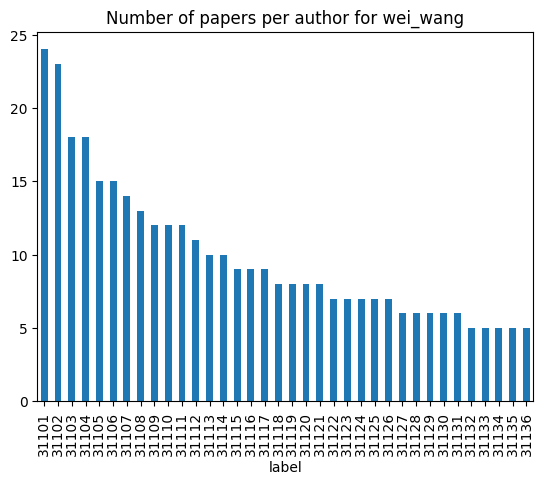

In [45]:
NAME = str(name_dropdown.value)

preprocessed[preprocessed["name"] == NAME]["label"].value_counts().plot(kind="bar", title=f"Number of papers per author for {NAME}")
plt.show()

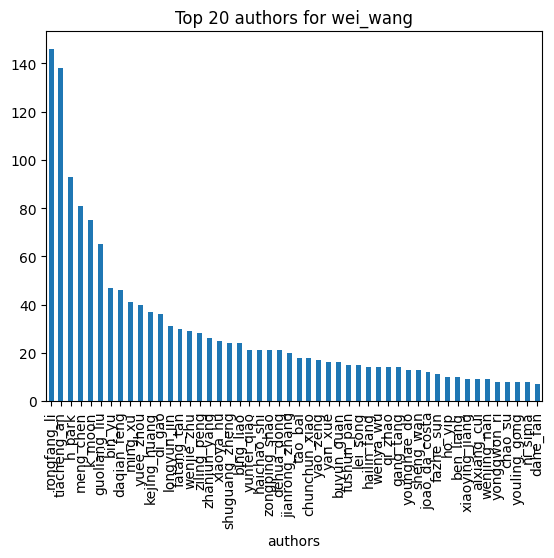

In [46]:
# parse authors from the preprocessed CSV and plot the distribution of orgs for the target name
authors = preprocessed[preprocessed["name"] == NAME]["authors"].dropna().apply(lambda x: eval(x) if isinstance(x, str) else [])
authors_exploded = authors.explode()
# remove empty authors and target name from the list of authors
authors_exploded = authors_exploded[~authors_exploded.isin(["", NAME])]
authors_exploded.value_counts().head(50).plot(kind="bar", title=f"Top 20 authors for {NAME}")
plt.show()

In [47]:
set(orgs_exploded.to_list())

{'ab',
 'aba teachers aba',
 'administrative',
 'albuquerque nm',
 'assessment ars ga',
 'assessment u poultry ars rd ga',
 'autom',
 'base eco pr',
 'bergen bergen',
 'binghamton binghamton ny',
 'binghamton po binghamton',
 'bioelectronics biosensors biodesign bb',
 'bioregulatory tokushima tokushima',
 'biotherapy biotherapy',
 'biotherapy p r',
 'bombay',
 'breeding ars tifton ga',
 'ca',
 'carbondale',
 'carbondale il',
 'carcinogenesis intervention tongjiaxiang',
 'chi prc',
 'clean gold',
 'coastal quaternary p r chinaf gjshen njnu cnf f clzhou njnu cnf',
 'colloid interface',
 'colloid interface n n',
 'colloid interface pr',
 'combinatorial biosynthesis',
 'combinatorial biosynthesis pr',
 'composite',
 'composite p r',
 'composite pr',
 'composite weijin',
 'cultural relics youjiang baise guangxi',
 'cybersecurity',
 'de f sica de la mat ria condensada de',
 'die mould',
 'die mould p r',
 'die mould pr',
 'ecological p r',
 'electronicsterahertz',
 'evanston',
 'f r carl von

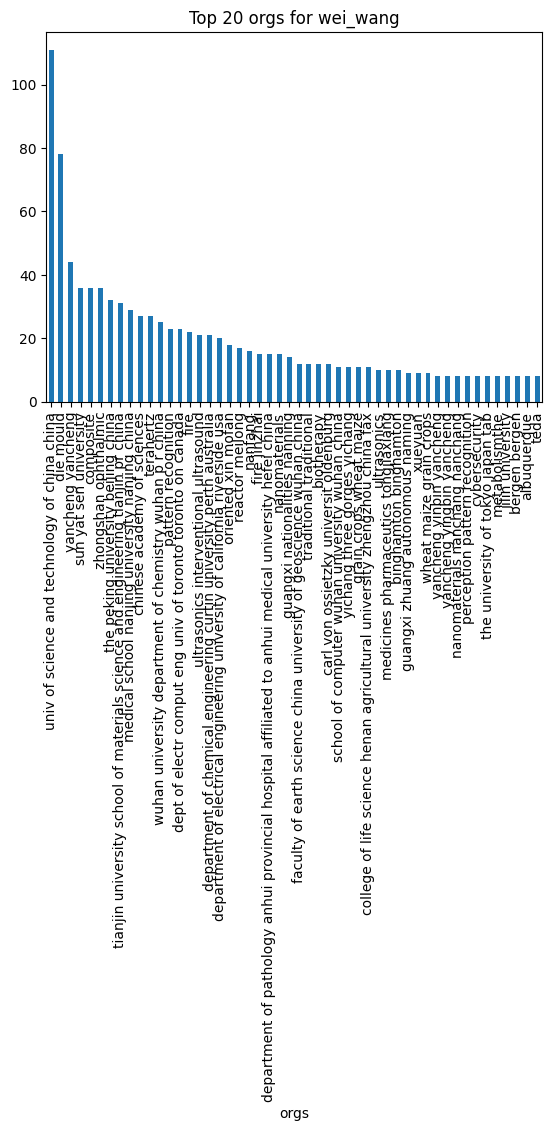

In [48]:
# parse orgs from the preprocessed CSV and plot the distribution of orgs for the target name
orgs = preprocessed[preprocessed["name"] == NAME]["orgs"].dropna().apply(lambda x: eval(x) if isinstance(x, str) else [])
orgs_exploded = orgs.explode()
# remove empty orgs
orgs_exploded = orgs_exploded[orgs_exploded != ""]
orgs_exploded.value_counts().head(50).plot(kind="bar", title=f"Top 20 orgs for {NAME}")
plt.show()

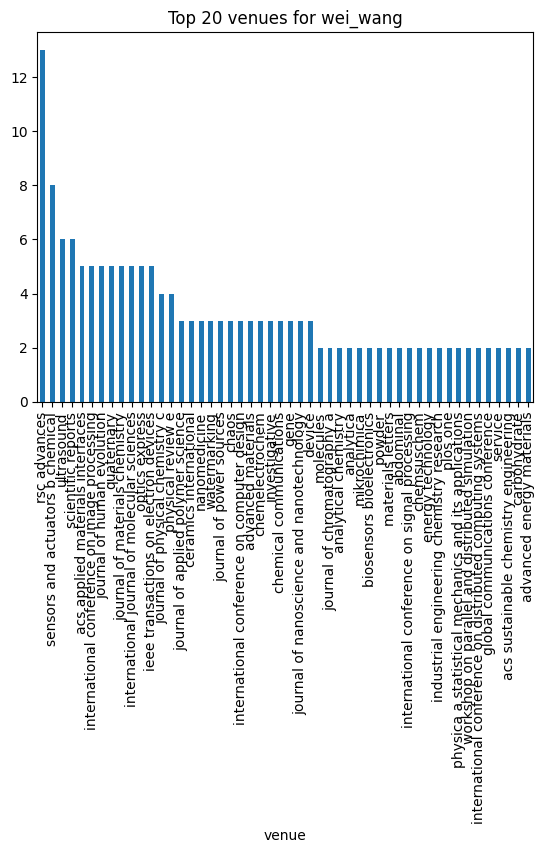

In [49]:
# parse venues from the preprocessed CSV and plot the distribution of orgs for the target name
venues = preprocessed[preprocessed["name"] == NAME]["venue"].dropna()
venues.value_counts().head(50).plot(kind="bar", title=f"Top 20 venues for {NAME}")
plt.show()

In [50]:
pubs_ids = preprocessed[preprocessed["name"] == NAME]["id"].tolist()
feats = torch.as_tensor(np.array([features[p_id] for p_id in pubs_ids]))
labels = torch.as_tensor(preprocessed[preprocessed["name"] == NAME]["label"].tolist())

plot_embeddings_plotly(feats, labels, NAME, paper_ids=preprocessed[preprocessed["name"] == NAME]["id"].tolist())

In [58]:
networks = torch.load(f"data/{DATASET}/networks_test.pt", weights_only=False)

net = [net for net in networks if net.name == NAME][0]

plot_hetero_graph_plotly(net, figsize=(10, 10), k=0.2)

In [ ]:
from andglore.trainer.trainer import run_andglore_experiment
from andglore.trainer.training_args import TrainingArgs

SEED = 2026

run_andglore_experiment(
        dataset_name=DATASET,
        networks_path=f"data/{DATASET}/networks_test.pt",
        training_args=TrainingArgs(
            seeds=(SEED,),
            epochs=50,
            lr=0.0001,
            l2_coef=0.0001,
            feat_mask=0.1,
            adj_mask=0.2,
            hidden_dim=128,
            embed_dim=64,
            proj_dim=64,
            dropout=0.1,
            gnn_hidden_dim=256,
            gnn_dropout=0.1,
            gnn_alpha=0.2,
            temperature=0.1,
            min_distance_threshold=0.1,
            max_distance_threshold=0.3,
            step=0.05,
            device="cuda",
        ),
        selected_names=[NAME],
        results_csv_path=None,
        outputs_path=f"outputs/{DATASET}-{NAME}.pt",  
        log_file_path=None 
    )

[2026-08-12 19:12:23] Starting Experiment

Experiments Args:seeds: (2026,)
epochs: 30
lr: 0.0001
l2_coef: 0.0001
feat_mask: 0.1
adj_mask: 0.2
hidden_dim: 128
embed_dim: 64
gnn_hidden_dim: 256
proj_dim: 64
temperature: 0.1
dropout: 0.1
gnn_dropout: 0.1
gnn_alpha: 0.2
min_distance_threshold: 0.1
max_distance_threshold: 0.15
step: 0.05
device: cuda

AND-GloRe Experiment:   0%|          | 0/1 [00:01<?, ?it/s, avg_pf1=0.00%, epoch=29/30, loss=2.48, name=0/1:wei_wang, run=1/1, seed=2026][2026-08-12 19:12:32] Results for name: wei_wang
Runtime: 0:00:01
pP: 54.97% pR: 35.63% pF1: 43.24%
bP: 77.90% bR: 44.16% bF1: 56.36%
ARI: 41.78%

AND-GloRe Experiment: 100%|██████████| 1/1 [00:01<00:00,  1.43s/it, avg_pf1=0.00%, epoch=29/30, loss=2.48, name=0/1:wei_wang, run=1/1, seed=2026]
[2026-08-12 19:12:32] Average Results Across All Names
Runtime: 0:00:01 (± 0:00:00)
pP: 54.97% (± 0.00%) pR: 35.63% (± 0.00%) pF1: 43.24% (± 0.00%)
bP: 77.90% (± 0.00%) bR: 44.16% (± 0.00%) bF1: 56.36% (± 0.00%)
ARI: 41.7

In [64]:
outputs = torch.load(f"outputs/{DATASET}-{NAME}.pt", weights_only=False)
paper_ids = preprocessed[preprocessed["name"] == NAME]["id"].tolist()
embeddings = outputs[SEED][NAME]["output"]
labels = outputs[SEED][NAME]["labels"]
pred = outputs[SEED][NAME]["pred"]

print(f"{'Label':>5}  Prediction")
print("-" * 20)
for label, prediction in zip(labels[:15], pred[:15]):
    print(f"{int(label):>5}  {prediction}")

Label  Prediction
--------------------
31101  43
31101  18
31101  51
31101  18
31101  51
31101  9
31101  18
31101  18
31101  18
31101  7
31101  18
31101  5
31101  51
31101  5
31101  23


In [65]:
plot_embeddings_plotly(embeddings, pred, NAME, paper_ids=paper_ids)

In [66]:
SEED = 2026

plot_embeddings_plotly(embeddings, labels, NAME, paper_ids=paper_ids)